# deliverable info
turn in py script where:
- unique property types found
- filtering logic applied
- null-count summary table
- missing value report that flags above 90% null
- numeric distrib summary (min, max, mean, median, percentiles)
    - ClosePrice
    - LivingArea
    - DaysOnMarket

save filtered dataset as new csv

### setup

In [14]:
# import stuff
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# load data from wk1 folder
folder = Path('../wk1')

listings = pd.read_csv(folder / 'listings.csv')
sold = pd.read_csv(folder / 'sold.csv')

C:\Users\User\AppData\Local\Temp\ipykernel_15768\3518173540.py:4: DtypeWarning: Columns (2,43) have mixed types. Specify dtype option on import or set low_memory=False.
  listings = pd.read_csv(folder / 'listings.csv')
C:\Users\User\AppData\Local\Temp\ipykernel_15768\3518173540.py:5: DtypeWarning: Columns (7,45,64,78,79,80,81) have mixed types. Specify dtype option on import or set low_memory=False.
  sold = pd.read_csv(folder / 'sold.csv')


# check sold dataset

### dataset understanding

In [3]:
# review col names
sold.columns

Index(['Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN',
       'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency',
       'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor',
       'TaxAnnualAmount', 'CountyOrParish', 'MlsStatus', 'ElementarySchool',
       'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType',
       'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt',
       'BuyerAgencyCompensationType', 'StreetNumberNumeric', 'ListingId',
       'BathroomsTotalInteger', 'City', 'Bu

In [4]:
# review dtypes
sold.dtypes

Flooring                         object
ViewYN                           object
WaterfrontYN                     object
BasementYN                       object
PoolPrivateYN                    object
                                 ...   
MiddleOrJuniorSchoolDistrict    float64
BuyerAgentAOR                    object
ListAgentAOR                     object
OriginatingSystemName            object
OriginatingSystemSubName         object
Length: 82, dtype: object

In [5]:
# review dataset shape & head
print(sold.shape)
sold.head()

(430716, 82)


,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,BuyerAgentAOR,ListAgentAOR,OriginatingSystemName,OriginatingSystemSubName
0,"Carpet,Tile,Wood",True,NaN,NaN,False,499000.0,551985747,jwachter@cbnorcal.com,2024-01-26,240000.0,...,1.0,Other,94401,6472.0,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,False,NaN,NaN,False,759900.0,522107581,mdarwich12@gmail.com,2024-01-05,815000.0,...,2.0,NaN,91950,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,False,NaN,NaN,False,739900.0,510919001,mdarwich12@gmail.com,2024-01-05,810000.0,...,2.0,NaN,91950,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,True,NaN,NaN,False,2100000.0,1067652762,jenniferarielkennedy@gmail.com,2024-01-02,2100000.0,...,3.0,San Luis Coastal Unified,93401,0.0,11219.0,NaN,NaN,NaN,NaN,NaN
4,Tile,True,NaN,NaN,False,1950000.0,1063453216,kira@mendosir.com,2024-01-22,1950000.0,...,2.0,NaN,95437,NaN,74487.6,NaN,NaN,NaN,NaN,NaN


In [6]:
# check property categories
sold['PropertyType'].unique()

# output: array(['Residential'], dtype=object)

array(['Residential'], dtype=object)

In [7]:
# validate completeness
sold.isnull().sum()

Flooring                        154655
ViewYN                           36867
WaterfrontYN                    430445
BasementYN                      422274
PoolPrivateYN                    36914
                                 ...  
MiddleOrJuniorSchoolDistrict    430716
BuyerAgentAOR                    63763
ListAgentAOR                     57390
OriginatingSystemName           369545
OriginatingSystemSubName        369545
Length: 82, dtype: int64

### missing val analysis
- null-count summary table
- flag cols w >90% missing vals
- decide what to drop vs retain

In [8]:
# null-count summary table
sold_null_count = sold.isnull().sum()
sold_null_percent = sold.isnull().mean() * 100

sold_null_summary = pd.DataFrame({
    'null count': sold_null_count,
    'null percent': sold_null_percent
})

sold_null_summary.sort_values(by = 'null percent', ascending = False).head(10)

,null count,null percent
ElementarySchoolDistrict,430716,100.000000
TaxAnnualAmount,430716,100.000000
FireplacesTotal,430716,100.000000
BusinessType,430716,100.000000
CoveredSpaces,430716,100.000000
TaxYear,430716,100.000000
MiddleOrJuniorSchoolDistrict,430716,100.000000
AboveGradeFinishedArea,430716,100.000000
WaterfrontYN,430445,99.937082
BelowGradeFinishedArea,428189,99.413303


In [10]:
# find cols w >90% nulls
over_90 = sold_null_summary[sold_null_summary['null percent'] > 90]
print('Columns with over 90% nulls:', over_90.shape[0])
# output: (15,2)

# prepare list of cols to flag if they have >90% nulls
cols_to_flag = over_90.index.tolist()
cols_to_flag

Columns with over 90% nulls: 15


['WaterfrontYN',
 'BasementYN',
 'FireplacesTotal',
 'AboveGradeFinishedArea',
 'TaxAnnualAmount',
 'BuilderName',
 'TaxYear',
 'BuildingAreaTotal',
 'ElementarySchoolDistrict',
 'CoBuyerAgentFirstName',
 'BelowGradeFinishedArea',
 'BusinessType',
 'CoveredSpaces',
 'LotSizeDimensions',
 'MiddleOrJuniorSchoolDistrict']

In [11]:
# exclude core fields from flagged list if there are any
core_fields = ['ClosePrice', 'ListPrice', 'OriginalListPrice',
               'LivingArea', 'LotSizeAcres', 'BedroomsTotal',
               'BathroomsTotalInteger', 'DaysOnMarket', 'YearBuilt']

for field in core_fields:
    if field in cols_to_flag:
        cols_to_flag.remove(field)

# check if any flagged cols were removed
print(len(cols_to_flag))
# cols_to_flag

15


### numeric distrib summary

In [12]:
sold_summary = sold[['ClosePrice', 'LivingArea', 'DaysOnMarket']].describe()
sold_summary

,ClosePrice,LivingArea,DaysOnMarket
count,4.307120e+05,4.304700e+05,430716.000000
mean,1.183795e+06,1.903930e+03,37.346802
std,5.667499e+06,2.595987e+04,53.681736
min,0.000000e+00,0.000000e+00,-288.000000
25%,5.750000e+05,1.248000e+03,8.000000
50%,8.250000e+05,1.644000e+03,18.000000
75%,1.300000e+06,2.221000e+03,48.000000
max,9.895000e+08,1.702132e+07,12430.000000


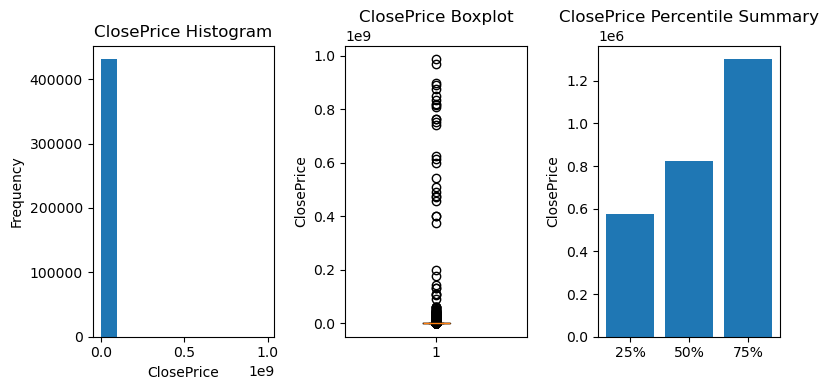

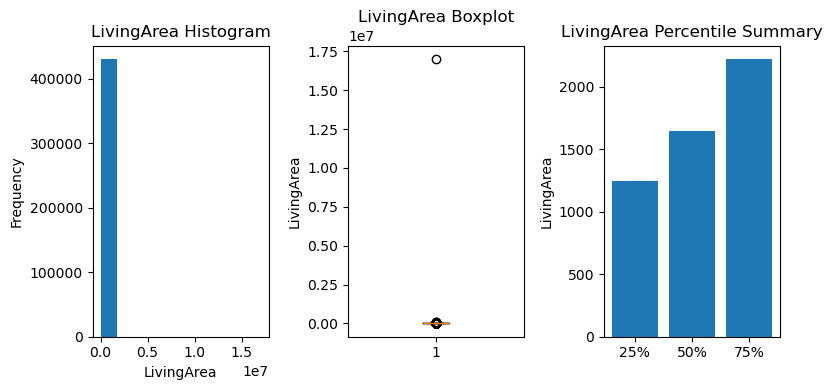

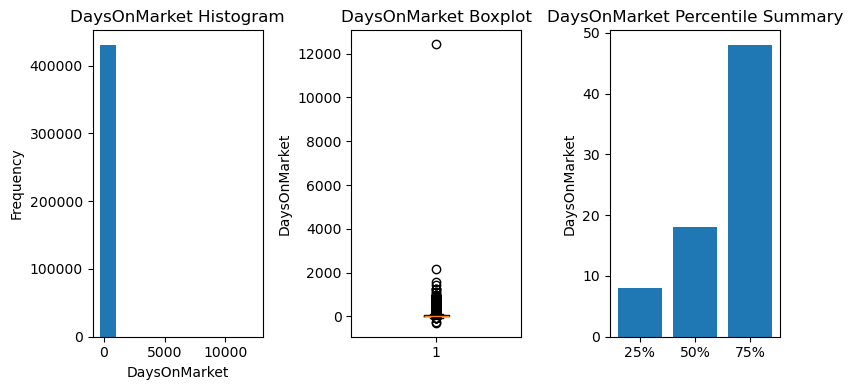

In [17]:
# visualizations for each numeric field (histograms, boxplots, and percentile summaries, and identify extreme outliers)
for col in ['ClosePrice', 'LivingArea', 'DaysOnMarket']:
    plt.figure(figsize=(12, 4))
    
    # histogram
    plt.subplot(1, 3, 1)
    plt.hist(sold[col].dropna())
    plt.title(f'{col} Histogram')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    
    # boxplot
    plt.subplot(1, 3, 2)
    plt.boxplot(sold[col].dropna())
    plt.title(f'{col} Boxplot')
    plt.ylabel(col)
    
    # percentile summary
    plt.subplot(1, 3, 3)
    percentiles = [25, 50, 75]
    vals = sold[col].quantile([p/100 for p in percentiles])
    plt.bar([f'{p}%' for p in percentiles], vals)
    plt.title(f'{col} Percentile Summary')
    plt.ylabel(col)
    
    plt.tight_layout()
    plt.show()

### save filtered dataset

In [ ]:
# save filtered dataset as new csv
# sold.to_csv('sold.csv', index = False)

# check listing dataset

### dataset understanding

In [42]:
# review col names
listings.columns

Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency',
       'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor',
       'TaxAnnualAmount', 'CountyOrParish', 'PropertyType.1', 'MlsStatus',
       'ElementarySchool', 'ListAgentFirstName.1', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'DaysOnMarket.1',
       'BuyerAgencyCompensationType', 'StreetNumberNumeric', 'LivingArea.1',
       'ListingId', 'BathroomsTotalInteger', 'Cit

In [43]:
# review dtypes
listings.dtypes

OriginalListPrice               float64
ListingKey                        int64
ListAgentEmail                   object
CloseDate                        object
ClosePrice                      float64
                                 ...   
BuyerOfficeName.1                object
AssociationFee                  float64
LotSizeSquareFeet               float64
MiddleOrJuniorSchoolDistrict    float64
UnparsedAddress.1                object
Length: 84, dtype: object

In [44]:
# review dataset shape & head
print(listings.shape)
listings.head()

(583650, 84)


,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress.1
0,1340000.0,1074973329,haleh360@Gmail.com,NaN,NaN,Haleh,Dowlatshahi,34.052207,-118.408445,2220 Avenue Of The Stars 2704,...,NaN,False,NaN,NaN,90067,NaN,2105.00,177861.0,NaN,2220 Avenue Of The Stars 2704
1,2500000.0,1074954552,Reneechen@yourhomesoldguaranteed.com,NaN,NaN,Renee,Chen,33.496363,-117.691677,16 Palisades,...,0.0,False,3.0,Capistrano Unified,92677,NaN,254.00,5300.0,NaN,16 Palisades
2,3150000.0,1074936537,anader@dppre.com,NaN,NaN,Margaret,Nader,34.119345,-118.111254,1615 Waverly Road,...,NaN,NaN,2.0,NaN,91108,NaN,NaN,9404.0,NaN,1615 Waverly Road
3,3090000.0,1074917818,QIANYU0607@GMAIL.COM,NaN,NaN,QIANYU,GUAN,33.984057,-117.802819,2250 Indian Creek Road,...,1.0,False,4.0,Walnut Valley Unified,91765,NaN,295.95,58232.0,NaN,2250 Indian Creek Road
4,12725000.0,1074143166,jeff.williams@pacificsir.com,NaN,NaN,Jeff,Williams,33.607583,-117.887743,317 E. Bayfront,...,3.0,False,2.0,Newport Mesa Unified,92662,NaN,0.00,2250.0,NaN,317 E. Bayfront


In [45]:
# check property categories
listings['PropertyType'].unique()

# output: array(['Residential'], dtype=object)

array(['Residential'], dtype=object)

In [46]:
# validate completeness
listings.isnull().sum()

OriginalListPrice                  850
ListingKey                           0
ListAgentEmail                   90468
CloseDate                       388215
ClosePrice                      408669
                                 ...  
BuyerOfficeName.1               397437
AssociationFee                  139655
LotSizeSquareFeet                46892
MiddleOrJuniorSchoolDistrict    583650
UnparsedAddress.1                  757
Length: 84, dtype: int64

### missing val analysis

In [49]:
# null-count summary table
listing_null_count = listings.isnull().sum()
listing_null_percent = listings.isnull().mean() * 100

listing_null_summary = pd.DataFrame({
    'null count': listing_null_count,
    'null percent': listing_null_percent
})

listing_null_summary.sort_values(by = 'null percent', ascending = False).head(10)

,null count,null percent
TaxAnnualAmount,583650,100.000000
FireplacesTotal,583650,100.000000
ElementarySchoolDistrict,583650,100.000000
TaxYear,583650,100.000000
BusinessType,583650,100.000000
MiddleOrJuniorSchoolDistrict,583650,100.000000
CoveredSpaces,583650,100.000000
AboveGradeFinishedArea,583650,100.000000
BelowGradeFinishedArea,580294,99.424998
CoBuyerAgentFirstName,566189,97.008310


In [50]:
# find cols w >90% nulls
over_90 = listing_null_summary[listing_null_summary['null percent'] > 90]
print('Columns with over 90% nulls:', over_90.shape[0])
# output: (15,2)

# prepare list of cols to flag if they have >90% nulls
cols_to_flag = over_90.index.tolist()
cols_to_flag

Columns with over 90% nulls: 13


['FireplacesTotal',
 'AboveGradeFinishedArea',
 'TaxAnnualAmount',
 'BuilderName',
 'TaxYear',
 'BuildingAreaTotal',
 'ElementarySchoolDistrict',
 'CoBuyerAgentFirstName',
 'BelowGradeFinishedArea',
 'BusinessType',
 'CoveredSpaces',
 'LotSizeDimensions',
 'MiddleOrJuniorSchoolDistrict']

In [51]:
# exclude core fields from flagged list if there are any
core_fields = ['ClosePrice', 'ListPrice', 'OriginalListPrice',
               'LivingArea', 'LotSizeAcres', 'BedroomsTotal',
               'BathroomsTotalInteger', 'DaysOnMarket', 'YearBuilt']

for field in core_fields:
    if field in cols_to_flag:
        cols_to_flag.remove(field)

# check if any flagged cols were removed
print(len(cols_to_flag))
# output: 13

13


### numeric distrib review

In [52]:
listings_summary = listings[['ClosePrice', 'LivingArea', 'DaysOnMarket']].describe()
listings_summary

,ClosePrice,LivingArea,DaysOnMarket
count,1.749810e+05,5.830650e+05,583650.000000
mean,1.201327e+06,1.979423e+03,20.942161
std,3.949219e+06,2.249945e+04,27.633067
min,5.250000e+02,0.000000e+00,-58.000000
25%,6.000000e+05,1.248000e+03,6.000000
50%,8.600000e+05,1.671000e+03,12.000000
75%,1.352000e+06,2.301000e+03,25.000000
max,8.200000e+08,1.702132e+07,1063.000000


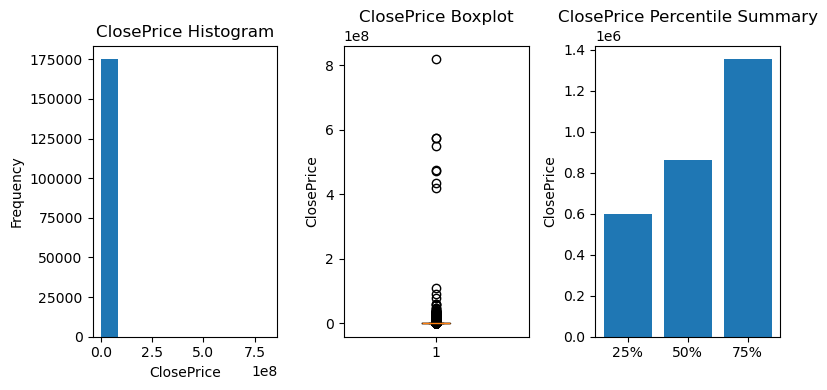

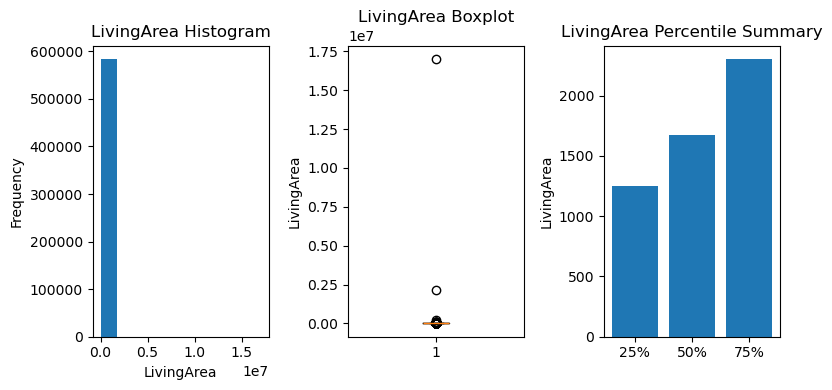

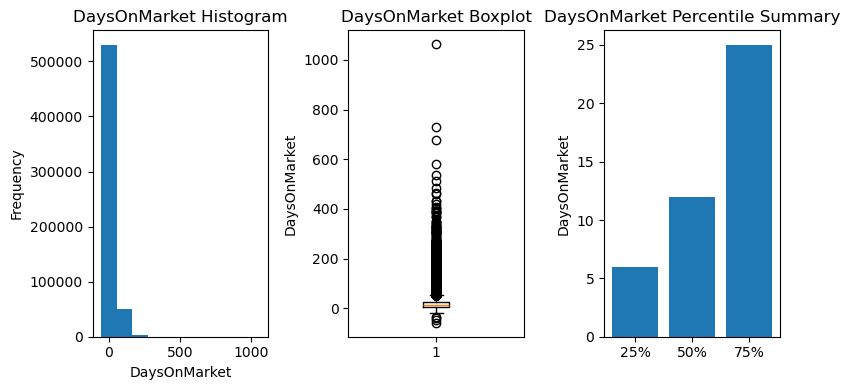

In [18]:
# visualizations for each numeric field (histograms, boxplots, and percentile summaries, and identify extreme outliers)
for col in ['ClosePrice', 'LivingArea', 'DaysOnMarket']:
    plt.figure(figsize=(12, 4))
    
    # histogram
    plt.subplot(1, 3, 1)
    plt.hist(listings[col].dropna())
    plt.title(f'{col} Histogram')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    
    # boxplot
    plt.subplot(1, 3, 2)
    plt.boxplot(listings[col].dropna())
    plt.title(f'{col} Boxplot')
    plt.ylabel(col)
    
    # percentile summary
    plt.subplot(1, 3, 3)
    percentiles = [25, 50, 75]
    vals = listings[col].quantile([p/100 for p in percentiles])
    plt.bar([f'{p}%' for p in percentiles], vals)
    plt.title(f'{col} Percentile Summary')
    plt.ylabel(col)
    
    plt.tight_layout()
    plt.show()

### save filtered dataset

In [ ]:
# save filtered dataset as new csv
# listings.to_csv('listings.csv', index = False)

# eda questions

### what are median & avg close prices

In [57]:
print('median close price', round(sold['ClosePrice'].median(), 2))
print('avg close price', round(sold['ClosePrice'].mean(), 2))

median close price 825000.0
avg close price 1183795.12


In [56]:
print('median close price', round(listings['ClosePrice'].median(), 2))
print('avg close price', round(listings['ClosePrice'].mean(), 2))

median close price 860000.0
avg close price 1201326.8


### look @ days on market distrib

In [58]:
sold['DaysOnMarket'].describe()

count    430716.000000
mean         37.346802
std          53.681736
min        -288.000000
25%           8.000000
50%          18.000000
75%          48.000000
max       12430.000000
Name: DaysOnMarket, dtype: float64

In [59]:
listings['DaysOnMarket'].describe()

count    583650.000000
mean         20.942161
std          27.633067
min         -58.000000
25%           6.000000
50%          12.000000
75%          25.000000
max        1063.000000
Name: DaysOnMarket, dtype: float64

### what % of homes sold above vs below list price

In [68]:
sold['ListPrice'].describe()

count    4.307160e+05
mean     1.141473e+06
std      1.356798e+06
min      5.250000e+02
25%      5.780000e+05
50%      8.188000e+05
75%      1.295000e+06
max      1.375000e+08
Name: ListPrice, dtype: float64

### any apparent date consistency issues (e.g close date before listing date)

### which counties have highest median prices

In [71]:
for col in sold.columns:
    if 'County' in col:
        print(col)

CountyOrParish


In [76]:
print(len(listing['CountyOrParish'].unique()))
listing['CountyOrParish'].unique()

63


array(['Los Angeles', 'Orange', 'San Diego', 'Riverside',
       'San Bernardino', 'Ventura', 'San Luis Obispo', 'Alameda',
       'Contra Costa', 'Santa Barbara', 'Lake', 'Fresno', 'Butte', 'Yolo',
       'Glenn', 'San Mateo', 'Tehama', 'Mendocino', 'Kern', 'Mariposa',
       'Santa Clara', 'Madera', 'Placer', 'Merced', 'Yuba', 'Napa',
       'Sacramento', 'Marin', 'Stanislaus', 'Santa Cruz', 'Solano',
       'Monterey', 'San Benito', 'San Francisco', 'Calaveras',
       'San Joaquin', 'Imperial', 'El Dorado', 'Mono', 'Other County',
       'Kings', 'Nevada', 'Tulare', 'Sonoma', 'Other State', 'Shasta',
       'Tuolumne', 'Foreign Country', 'Siskiyou', 'Sutter', 'Plumas',
       'Humboldt', 'Colusa', 'Amador', 'Trinity', 'Del Norte', 'Inyo',
       'Lassen', 'Modoc', 'Alpine', 'Other', 'Sierra', 'Clark'],
      dtype=object)

In [78]:
sold_median_prices = sold.groupby('CountyOrParish')['ListPrice'].median()
sold_median_prices

CountyOrParish
Alameda      1000000.0
Alpine       1295000.0
Amador        417500.0
Butte         399250.0
Calaveras     499000.0
               ...    
Tulare        394500.0
Tuolumne      389000.0
Ventura       874900.0
Yolo          619000.0
Yuba          419000.0
Name: ListPrice, Length: 63, dtype: float64

In [79]:
listing_median_prices = listings.groupby('CountyOrParish')['ListPrice'].median()
listing_median_prices

CountyOrParish
Alameda      998000.0
Alpine       558125.0
Amador       505000.0
Butte        405000.0
Calaveras    524874.5
               ...   
Tulare       406950.0
Tuolumne     422450.0
Ventura      899000.0
Yolo         612000.0
Yuba         428750.0
Name: ListPrice, Length: 63, dtype: float64